In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

# Use the kagglehub client library to attach Kaggle resources like competitions, datasets, and models to your session
# Learn more about kagglehub: https://github.com/Kaggle/kagglehub/blob/main/README.md

import kagglehub
# kagglehub.dataset_download('<owner>/<dataset-slug>')

/kaggle/input/datasets/ihelon/coffee-sales/index_2.csv
/kaggle/input/datasets/ihelon/coffee-sales/index_1.csv


In [2]:
# Chargement du fichier dans un DataFrame
df = pd.read_csv('/kaggle/input/datasets/ihelon/coffee-sales/index_1.csv')

# Affichage des 5 premières lignes
df.head()

,date,datetime,cash_type,card,money,coffee_name
0,2024-03-01,2024-03-01 10:15:50.520,card,ANON-0000-0000-0001,38.7,Latte
1,2024-03-01,2024-03-01 12:19:22.539,card,ANON-0000-0000-0002,38.7,Hot Chocolate
2,2024-03-01,2024-03-01 12:20:18.089,card,ANON-0000-0000-0002,38.7,Hot Chocolate
3,2024-03-01,2024-03-01 13:46:33.006,card,ANON-0000-0000-0003,28.9,Americano
4,2024-03-01,2024-03-01 13:48:14.626,card,ANON-0000-0000-0004,38.7,Latte


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 3636 entries, 0 to 3635
Data columns (total 6 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   date         3636 non-null   object 
 1   datetime     3636 non-null   object 
 2   cash_type    3636 non-null   object 
 3   card         3547 non-null   object 
 4   money        3636 non-null   float64
 5   coffee_name  3636 non-null   object 
dtypes: float64(1), object(5)
memory usage: 170.6+ KB


In [4]:
df.describe()

,money
count,3636.000000
mean,31.746859
std,4.919926
min,18.120000
25%,27.920000
50%,32.820000
75%,35.760000
max,40.000000


In [5]:

# Compter le nombre de ventes par type de café
df['coffee_name'].value_counts()

coffee_name
Americano with Milk    824
Latte                  782
Americano              578
Cappuccino             501
Cortado                292
Hot Chocolate          282
Cocoa                  243
Espresso               134
Name: count, dtype: int64

/tmp/ipykernel_16/3456010620.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(


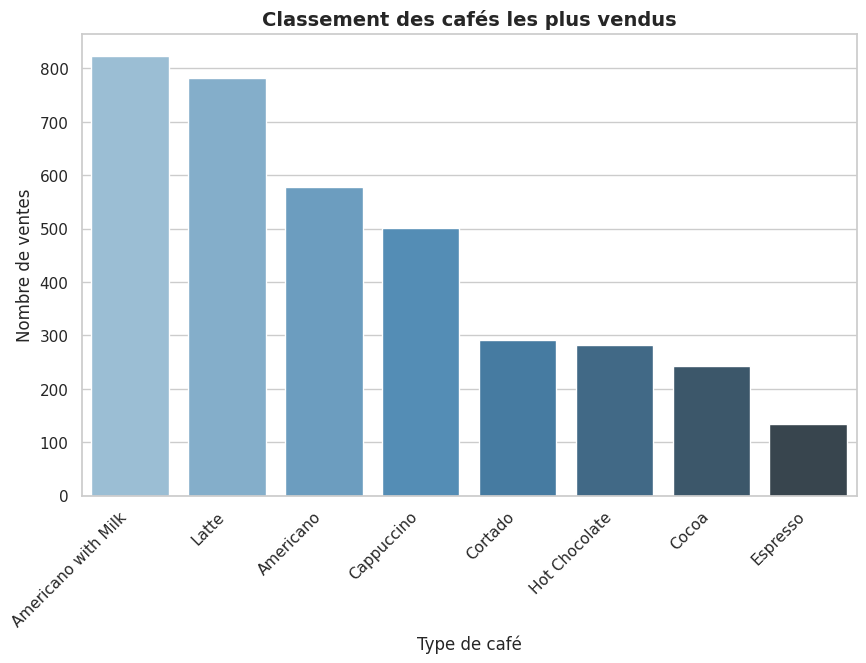

In [6]:
import matplotlib.pyplot as plt
import seaborn as sns

# Choisir un style sympa pour le fond
sns.set_theme(style="whitegrid")

# Créer la figure
plt.figure(figsize=(10, 6))

# Tracer le diagramme en barres avec Seaborn
sns.countplot(
    data=df,
    x='coffee_name',
    order=df['coffee_name'].value_counts().index,  # Trie du plus grand au plus petit
    palette='Blues_d'
)

# Ajouter des titres et personnaliser
plt.title("Classement des cafés les plus vendus", fontsize=14, fontweight='bold')
plt.xlabel("Type de café", fontsize=12)
plt.ylabel("Nombre de ventes", fontsize=12)

# Faire pivoter les étiquettes des axes pour qu'elles soient lisibles
plt.xticks(rotation=45, ha='right')

# Afficher le graphique
plt.show()

l'EXPRESSO est le moins vendu et AMERICANO WITH MILK est le plus vendu


In [7]:
#pour savoir le nombre de chaque type de paiement
df["cash_type"].value_counts()

cash_type
card    3547
cash      89
Name: count, dtype: int64

La plupart des ventes s'effectue par carte

In [8]:
# Prix et nombre de ventes par type de café
df.groupby('coffee_name')['money'].agg(['min', 'max', 'count'])

,min,max,count
coffee_name,,,
Americano,23.02,30.0,578
Americano with Milk,27.92,35.0,824
Cappuccino,32.82,40.0,501
Cocoa,32.82,40.0,243
Cortado,23.02,30.0,292
Espresso,18.12,25.0,134
Hot Chocolate,32.82,40.0,282
Latte,32.82,40.0,782


L'Espresso est le produit le moins cher mais le moins vendu, tandis que les boissons avec du lait dominent les ventes.

In [9]:
# Trier du café le plus vendu au moins vendu
df.groupby('coffee_name')['money'].agg(['min', 'max', 'count']).sort_values(by='count', ascending=False)

,min,max,count
coffee_name,,,
Americano with Milk,27.92,35.0,824
Latte,32.82,40.0,782
Americano,23.02,30.0,578
Cappuccino,32.82,40.0,501
Cortado,23.02,30.0,292
Hot Chocolate,32.82,40.0,282
Cocoa,32.82,40.0,243
Espresso,18.12,25.0,134


## Conclusion et Synthèse de l'Analyse

Cette analyse exploratoire des données de vente du distributeur automatique met en évidence plusieurs tendances clés.

---

### Synthèse des résultats

* **Comportement des consommateurs :** Les clients ne privilégient pas nécessairement le prix le plus bas. L'Espresso, qui est la boisson la moins chère (de 18.12 à 25.00), enregistre le volume de ventes le plus faible avec seulement 134 tasses écoulées.
* **Produits les plus vendus :** Les boissons composées ou contenant du lait dominent largement le chiffre d'affaires. L'Americano avec lait (824 ventes) et le Latte (782 ventes) représentent la majeure partie de la consommation.
* **Modes de paiement :** L'utilisation de la carte bancaire est nettement prédominante, couvrant environ 97,5 % des transactions. Le paiement en espèces reste très minoritaire avec seulement 89 transactions.

---

### Recommandations

1. **Gestion des stocks :** Assurer un réapprovisionnement régulier et prioritaire en lait pour éviter toute rupture sur les deux boissons les plus demandées.
2. **Maintenance des équipements :** Garantir le bon fonctionnement du terminal de paiement par carte bancaire, son indisponibilité impactant la quasi-totalité des clients.
3. **Optimisation de la carte :** Envisager des ajustements sur les produits moins populaires comme l'Espresso, par exemple en proposant des promotions ou en testant de nouvelles déclinaisons.